In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 13,
    'font.family': 'serif',
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'lines.linewidth': 2,
    'lines.markersize': 6,
})

## Neutrino Oscillation: Classical Two-Flavor Model

**Channel modeled:** atmospheric (ν_μ ↔ ν_τ), two-flavor approximation
**Mass ordering:** normal ordering
**Parameters (NuFIT 6.0, 2024 — Esteban et al., JHEP 12 (2024) 216, nu-fit.org):**
- θ₂₃ = 43.3° = 0.7557 rad
- Δm²₃₁ = 2.5 × 10⁻³ eV²

**Physical background:**
A neutrino is produced and detected as a specific flavor (electron, muon, or tau),
but travels as a mixture of mass states. Because these mass states have slightly
different masses, they accumulate different quantum phases as the neutrino
propagates. This phase difference causes the flavor composition to oscillate
periodically with distance traveled, governed by the ratio L/E (distance over
energy), not by L alone. This is why the correct independent variable for this
study is L/E, not raw distance.

Sanity check passed. P range: [0.0000, 0.9965]
Survival + transition = 1.000000 to 1.000000 (should be 1.0)


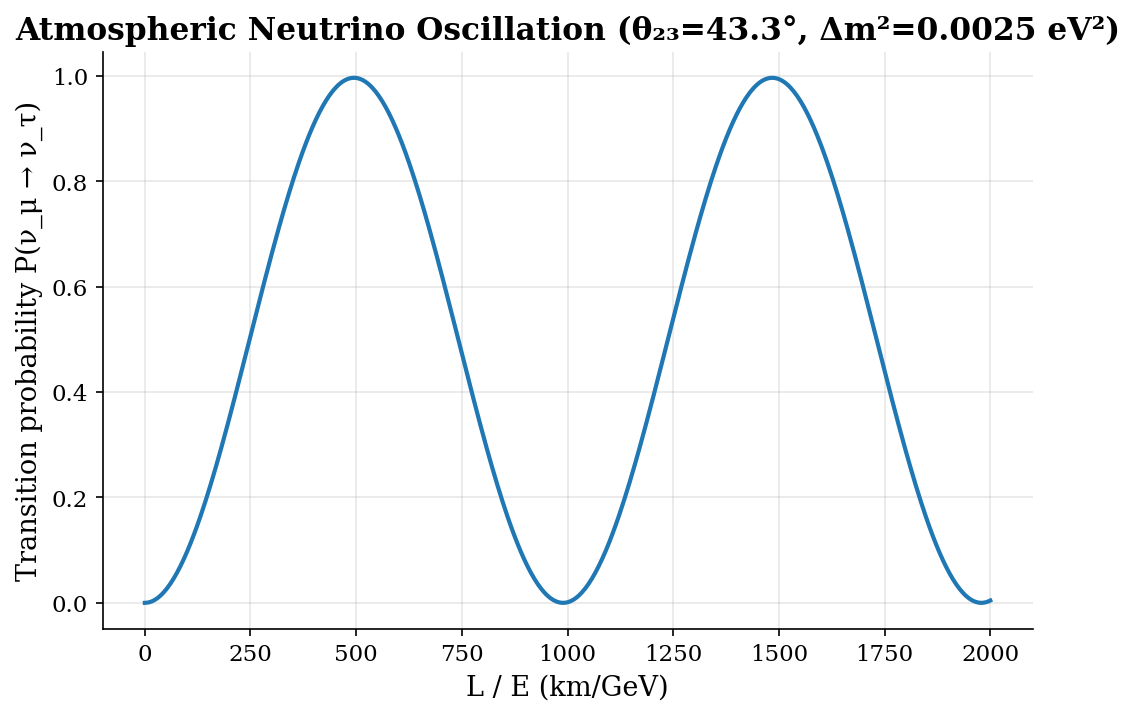

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Physical parameters (NuFIT 6.0, 2024, normal ordering) ---
theta_23_deg = 43.3
theta = np.deg2rad(theta_23_deg)     # 0.7557 rad
delta_m2 = 2.5e-3                     # eV^2, atmospheric splitting (Δm²31)

# Note: the constant 1.27 in the formula below assumes L in km, E in GeV,
# and Δm² in eV² — no further unit conversion is needed when using these units.

L_over_E = np.linspace(0.1, 2000, 500)   # km/GeV, avoid exactly 0 to prevent div issues later
P = (np.sin(2*theta)**2) * (np.sin(1.27 * delta_m2 * L_over_E)**2)

# Sanity check: probability must stay within [0, 1]
assert np.all(P >= -1e-10) and np.all(P <= 1 + 1e-10), "Probability out of bounds!"
print(f"Sanity check passed. P range: [{P.min():.4f}, {P.max():.4f}]")

# Survival probability check: P_survival + P_transition = 1
P_survival = 1 - P
print(f"Survival + transition = {(P + P_survival).min():.6f} to {(P + P_survival).max():.6f} (should be 1.0)")

plt.figure(figsize=(8,5))
plt.plot(L_over_E, P)
plt.xlabel("L / E (km/GeV)")
plt.ylabel("Transition probability P(ν_μ → ν_τ)")
plt.title(f"Atmospheric Neutrino Oscillation (θ₂₃={theta_23_deg}°, Δm²={delta_m2} eV²)")
plt.grid(True)
plt.savefig("fig1_classical_oscillation.png", dpi=200, bbox_inches='tight')
plt.show()